### House Price Regression — Phase 4: Evaluation & Storytelling
### Ames Housing Dataset
 
Steps:
  1. Load processed data + retrain best model
  2. Business-friendly error analysis (dollar error by price range)
  3. Feature importance narrative (what adds value to a home?)
  4. Top outliers — where did the model go wrong and why?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")
 
plt.rcParams.update({"figure.facecolor": "white", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e5e5e5"})
 
SEED = 42

###  LOAD DATA & RETRAIN BEST MODEL

In [2]:
df = pd.read_csv("train_processed.csv")
 
X = df.drop(columns=["LogSalePrice"])
y = df["LogSalePrice"]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
 
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, subsample=0.8, random_state=SEED
    ))
])
pipe.fit(X_train, y_train)
 
y_pred_log  = pipe.predict(X_test)
y_pred_real = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)
 
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))
test_r2   = r2_score(y_test, y_pred_log)
dollar_err = np.expm1(test_rmse)
 
print("=" * 60)
print("BEST MODEL — Gradient Boosting Regressor")
print("=" * 60)
print(f"  Test RMSE (log) : {test_rmse:.4f}")
print(f"  Test R²         : {test_r2:.4f}")
print(f"  Avg $ error     : ${dollar_err:,.0f}")

BEST MODEL — Gradient Boosting Regressor
  Test RMSE (log) : 0.1049
  Test R²         : 0.9405
  Avg $ error     : $0


### DOLLAR ERROR BY PRICE RANGE


Error by Price Range:
            Count  MeanAbsErr  MeanPctErr
PriceRange                               
<$100k         51      9472.9        12.8
$100–150k     191      9004.8         7.1
$150–200k     147     11348.5         6.5
$200–250k      83     13468.7         6.0
$250–300k      49     18024.6         6.7
>$300k         65     34224.6         8.4


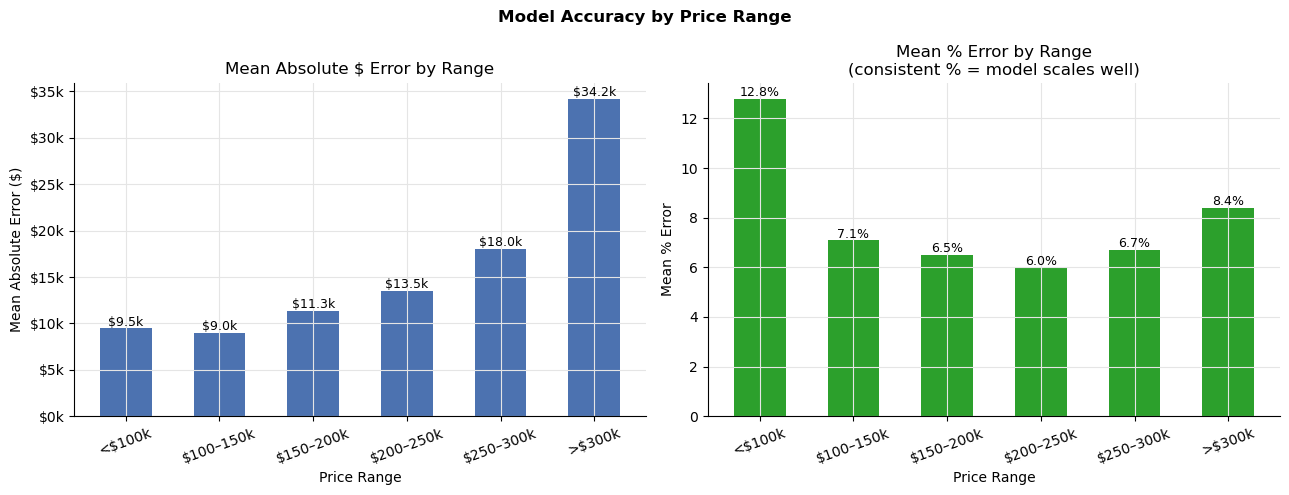

In [3]:
#    Business question: is the model equally accurate across all price points?

 
eval_df = pd.DataFrame({
    "Actual"    : y_test_real.values,
    "Predicted" : y_pred_real,
    "AbsError"  : np.abs(y_test_real.values - y_pred_real),
    "PctError"  : np.abs(y_test_real.values - y_pred_real) / y_test_real.values * 100,
})
 
bins   = [0, 100_000, 150_000, 200_000, 250_000, 300_000, 999_999]
labels = ["<$100k", "$100–150k", "$150–200k", "$200–250k", "$250–300k", ">$300k"]
eval_df["PriceRange"] = pd.cut(eval_df["Actual"], bins=bins, labels=labels)
 
range_summary = (eval_df.groupby("PriceRange", observed=False)
                         .agg(Count=("Actual", "count"),
                              MeanAbsErr=("AbsError", "mean"),
                              MeanPctErr=("PctError", "mean"))
                         .round(1))
 
print("\nError by Price Range:")
print(range_summary.to_string())
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Model Accuracy by Price Range", fontweight="bold")
 
# Panel 1: Mean absolute $ error per range
ax = axes[0]
bars = ax.bar(range_summary.index, range_summary["MeanAbsErr"],
              color="#4C72B0", width=0.55)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.set_xlabel("Price Range")
ax.set_ylabel("Mean Absolute Error ($)")
ax.set_title("Mean Absolute $ Error by Range")
ax.tick_params(axis="x", rotation=20)
for bar, v in zip(bars, range_summary["MeanAbsErr"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f"${v/1000:.1f}k", ha="center", fontsize=9)
 
# Panel 2: Mean % error per range
ax = axes[1]
bars2 = ax.bar(range_summary.index, range_summary["MeanPctErr"],
               color="#2ca02c", width=0.55)
ax.set_xlabel("Price Range")
ax.set_ylabel("Mean % Error")
ax.set_title("Mean % Error by Range\n(consistent % = model scales well)")
ax.tick_params(axis="x", rotation=20)
for bar, v in zip(bars2, range_summary["MeanPctErr"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{v:.1f}%", ha="center", fontsize=9)
 
plt.tight_layout()
plt.savefig("phase4_error_by_range.png", dpi=150, bbox_inches="tight")
plt.show()

### FEATURE IMPORTANCE — BUSINESS NARRATIVE

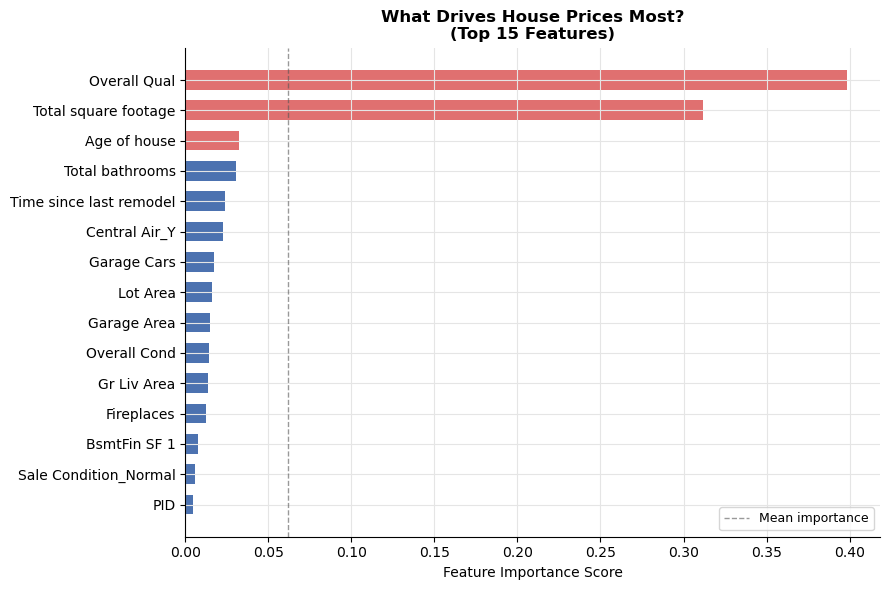


Business narrative — Top 5 price drivers:
  Overall Qual                        importance=0.3983
  Total square footage                importance=0.3119
  Age of house                        importance=0.0327
  Total bathrooms                     importance=0.0304
  Time since last remodel             importance=0.0238


In [4]:
#    Translate model weights into plain English renovation advice

 
importances = pd.Series(
    pipe.named_steps["model"].feature_importances_,
    index=X.columns
).sort_values(ascending=False)
 
top15 = importances.head(15)
 
# Plain-English labels for the top features
LABELS = {
    "OverallQual"         : "Overall build quality",
    "TotalSF"             : "Total square footage",
    "GrLivArea"           : "Above-ground living area",
    "TotalBsmtSF"         : "Basement size",
    "GarageCars"          : "Garage capacity (cars)",
    "HouseAge"            : "Age of house",
    "RemodAge"            : "Time since last remodel",
    "1stFlrSF"            : "1st floor area",
    "ExterQual"           : "Exterior material quality",
    "KitchenQual"         : "Kitchen quality",
    "GarageArea"          : "Garage area",
    "BsmtQual"            : "Basement height/quality",
    "TotalBaths"          : "Total bathrooms",
    "FireplaceQu"         : "Fireplace quality",
    "LotArea"             : "Lot size",
}
 
top15_labelled = top15.copy()
top15_labelled.index = [LABELS.get(i, i) for i in top15.index]
 
fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#E07070" if i < 3 else "#4C72B0" for i in range(len(top15_labelled))]
ax.barh(top15_labelled.index[::-1], top15_labelled.values[::-1],
        color=colors[::-1], height=0.65)
ax.set_xlabel("Feature Importance Score")
ax.set_title("What Drives House Prices Most?\n(Top 15 Features)", fontweight="bold")
ax.axvline(top15_labelled.mean(), color="#555", linestyle="--",
           linewidth=1, alpha=0.6, label="Mean importance")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("phase4_feature_importance_narrative.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("\nBusiness narrative — Top 5 price drivers:")
for feat, score in top15.head(5).items():
    label = LABELS.get(feat, feat)
    print(f"  {label:<35} importance={score:.4f}")

### OUTLIER ANALYSIS — WHERE DID THE MODEL GO WRONG?


Top 5 OVER-predictions (model overestimated price):
       Actual Predicted  AbsError  Residual
570  $135,000   $80,801   $54,199     0.513
60    $60,000   $40,090   $19,910     0.403
34   $128,500   $89,910   $38,590     0.357
173  $611,657  $444,882  $166,775     0.318
6    $200,000  $149,440   $50,560     0.291

Top 5 UNDER-predictions (model underestimated price):
       Actual Predicted  AbsError  Residual
89   $184,750  $397,882  $213,132    -0.767
369   $60,000   $99,771   $39,771    -0.509
215   $50,000   $81,481   $31,481    -0.488
251   $66,500   $96,342   $29,842    -0.371
117  $235,000  $324,916   $89,916    -0.324


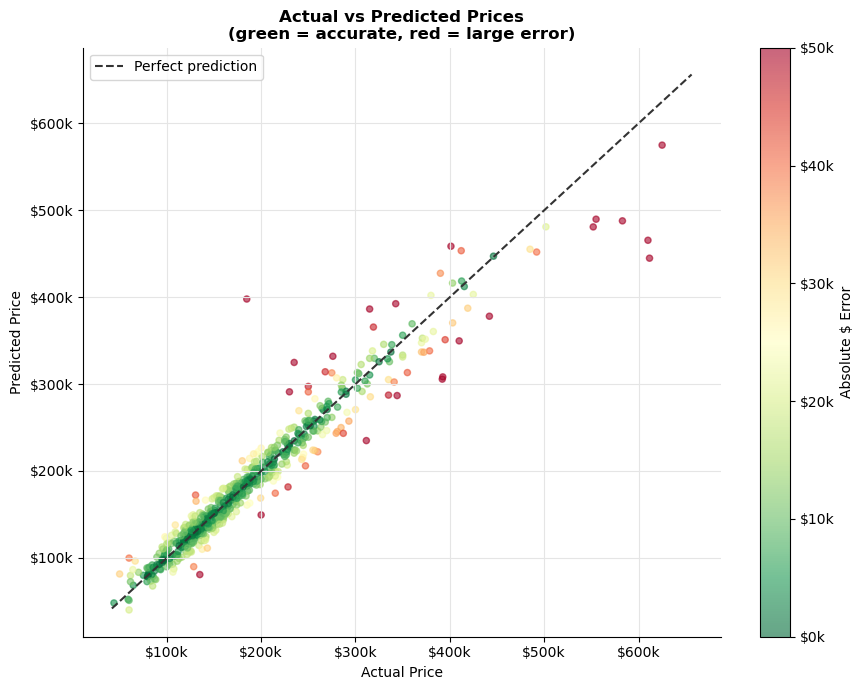

In [5]:
eval_df["LogActual"]    = y_test.values
eval_df["LogPredicted"] = y_pred_log
eval_df["Residual"]     = y_test.values - y_pred_log
 
# Top 5 over-predicted (model thought house was worth more than it sold for)
over  = eval_df.nlargest(5, "Residual")[["Actual","Predicted","AbsError","Residual"]]
# Top 5 under-predicted (model undervalued the house)
under = eval_df.nsmallest(5, "Residual")[["Actual","Predicted","AbsError","Residual"]]
 
print("\nTop 5 OVER-predictions (model overestimated price):")
print(over.applymap(lambda x: f"${x:,.0f}" if abs(x) > 100 else round(x, 3)).to_string())
 
print("\nTop 5 UNDER-predictions (model underestimated price):")
print(under.applymap(lambda x: f"${x:,.0f}" if abs(x) > 100 else round(x, 3)).to_string())
 
# Scatter: Actual vs Predicted coloured by absolute error
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(eval_df["Actual"], eval_df["Predicted"],
                c=eval_df["AbsError"], cmap="RdYlGn_r",
                alpha=0.6, s=20, vmin=0, vmax=50_000)
lims = [eval_df["Actual"].min() * 0.95, eval_df["Actual"].max() * 1.05]
ax.plot(lims, lims, "--", color="#333", linewidth=1.5, label="Perfect prediction")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Absolute $ Error")
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.set_xlabel("Actual Price")
ax.set_ylabel("Predicted Price")
ax.set_title("Actual vs Predicted Prices\n(green = accurate, red = large error)",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("phase4_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()